In [1]:
import sys
from pathlib import Path
from types import SimpleNamespace

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from data.clean_data import basic_clean
from data.load_data import load_raw_data
from data.feature_engineering import prepare_model_data
from data.model_features import get_grouped_model_feature_columns, split_feature_types
from models.gradient_boosting import (
    build_gradient_boosting_pipeline,
    predict_gradient_boosting,
    transform_target,
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", "{:,.4f}".format)

In [2]:
df_raw = load_raw_data()
df = basic_clean(df_raw)

target = "annual_medical_cost"
log_target = f"log1p_{target}"

df = prepare_model_data(
    df,
    target_col=target,
    add_log=True,
    add_groups=True,
    add_tail_flags=False,
)

feature_cols = get_grouped_model_feature_columns(
    df,
    target_col=target,
)

print("Prepared portfolio shape:", df.shape)
print("Number of model features before encoding:", len(feature_cols))

display(df.head())
display(pd.Series(feature_cols, name="model_features"))

Prepared portfolio shape: (100000, 58)
Number of model features before encoding: 47


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,bmi,smoker,alcohol_freq,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,systolic_bp,diastolic_bp,ldl,hba1c,plan_type,network_tier,deductible,copay,policy_term_years,policy_changes_last_2yrs,provider_quality,risk_score,annual_medical_cost,annual_premium,monthly_premium,claims_count,avg_claim_amount,total_claims_paid,chronic_count,hypertension,diabetes,asthma,copd,cardiovascular_disease,cancer_history,kidney_disease,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure,log1p_annual_medical_cost,hospitalizations_grouped,chronic_count_grouped,days_hospitalized_grouped
0,75722,52,Female,North,Suburban,"22,700.0000",Doctorate,Married,Retired,3,1,27.4000,Never,NaN,2,0,0,4,121.0000,76.0000,123.8000,5.2800,PPO,Bronze,1000,20,4,0,3.7300,0.5714,"6,938.0600",876.0500,73.0000,1,"4,672.5900","4,672.5900",1,0,0,0,0,0,0,0,0,1,0,1,0,2,0,1,0,0,8.8449,0,1,0
1,80185,79,Female,North,Urban,"12,800.0000",No HS,Married,Employed,3,1,26.6000,Never,Weekly,2,0,0,3,131.0000,79.0000,97.3000,4.8200,POS,Gold,1000,10,1,0,3.1000,1.0000,"1,632.6100",445.1000,37.0900,4,297.2700,"1,189.0800",2,0,0,0,0,0,0,0,0,1,1,0,0,1,0,1,1,0,7.3985,0,2,0
2,19865,68,Male,North,Rural,"40,700.0000",HS,Married,Retired,5,3,31.5000,Never,NaN,1,0,0,4,160.0000,84.0000,129.5000,5.5100,HMO,Platinum,500,20,10,0,3.9000,1.0000,"7,661.0100","1,538.0200",128.1700,0,0.0000,0.0000,3,1,0,0,0,0,1,0,0,0,1,1,0,2,1,0,1,0,8.9440,0,3,0
3,76700,15,Male,North,Suburban,"15,600.0000",Some College,Married,Self-employed,5,3,31.6000,Never,NaN,0,0,0,1,104.0000,68.0000,160.3000,8.5000,HMO,Silver,500,20,5,0,3.8900,0.2857,"5,130.2700",820.6300,68.3900,0,0.0000,0.0000,1,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,8.5431,0,1,0
4,92992,53,Male,Central,Suburban,"89,600.0000",Doctorate,Married,Self-employed,2,0,30.5000,Never,Daily,3,0,0,2,136.0000,83.0000,171.0000,5.2000,POS,Platinum,500,10,7,0,3.9000,0.8681,"1,700.7300",500.9300,41.7400,1,"1,002.2400","1,002.2400",2,1,0,0,0,0,0,0,0,1,0,2,0,1,1,0,1,0,7.4394,0,2,0


0                           age
1                           sex
2                        region
3                   urban_rural
4                        income
5                     education
6                marital_status
7             employment_status
8                household_size
9                    dependents
10                          bmi
11                       smoker
12                 alcohol_freq
13             visits_last_year
14             medication_count
15                  systolic_bp
16                 diastolic_bp
17                          ldl
18                        hba1c
19                    plan_type
20                 network_tier
21                   deductible
22                        copay
23            policy_term_years
24     policy_changes_last_2yrs
25             provider_quality
26                   risk_score
27                 hypertension
28                     diabetes
29                       asthma
30                         copd
31      

In [3]:
RANDOM_STATE = 42
TARGET_TRANSFORM = "log1p"

SELECTED_STRESS_MODEL_CONFIG = {
    "name": "tail_weighted_squared_error",
    "loss": "squared_error",
    "target_transform": TARGET_TRANSFORM,
    "n_estimators": 300,
    "learning_rate": 0.05,
    "max_depth": 3,
    "subsample": 1.0,
    "gradient_boosting_params": None,
    "p95_weight": 5.0,
    "p99_weight": 10.0,
}

STRESS_LEVELS = {
    "mild": 0.10,
    "moderate": 0.20,
    "severe": 0.30,
}

TAIL_QUANTILES = (0.90, 0.95, 0.99)

OUTPUT_DIR = PROJECT_ROOT / "Outputs" / "07_stress_scenario_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

display(pd.Series(SELECTED_STRESS_MODEL_CONFIG, name="selected_stress_model_config"))
display(pd.Series(STRESS_LEVELS, name="stress_levels"))
print("Output directory:", OUTPUT_DIR)

name                        tail_weighted_squared_error
loss                                      squared_error
target_transform                                  log1p
n_estimators                                        300
learning_rate                                    0.0500
max_depth                                             3
subsample                                        1.0000
gradient_boosting_params                           None
p95_weight                                       5.0000
p99_weight                                      10.0000
Name: selected_stress_model_config, dtype: object

mild       0.1000
moderate   0.2000
severe     0.3000
Name: stress_levels, dtype: float64

Output directory: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\07_stress_scenario_analysis


In [4]:
def make_tail_sample_weights(y_values, p95_weight=5.0, p99_weight=10.0):
    y_series = pd.Series(y_values, dtype="float64")

    p95 = float(y_series.quantile(0.95))
    p99 = float(y_series.quantile(0.99))

    y_array = y_series.to_numpy()
    weights = np.ones(len(y_array), dtype=float)

    weights[y_array >= p95] = float(p95_weight)
    weights[y_array >= p99] = float(p99_weight)

    return weights


def fit_tail_weighted_gradient_boosting_full_portfolio(
        input_df,
        target_col,
        selected_feature_cols,
        config,
        random_state=42,
):
    x = input_df[selected_feature_cols].copy()
    y = input_df[target_col].copy()

    y_transformed = transform_target(
        y,
        target_transform=config["target_transform"],
    )

    numeric_cols, categorical_cols = split_feature_types(
        x,
        selected_feature_cols,
    )

    model = build_gradient_boosting_pipeline(
        numeric_cols=numeric_cols,
        categorical_cols=categorical_cols,
        loss=config["loss"],
        quantile_alpha=None,
        n_estimators=int(config["n_estimators"]),
        learning_rate=float(config["learning_rate"]),
        max_depth=int(config["max_depth"]),
        subsample=float(config["subsample"]),
        random_state=random_state,
        gradient_boosting_params=config.get("gradient_boosting_params"),
        numeric_impute_strategy="median",
        categorical_impute_strategy="most_frequent",
        scale_numeric=False,
        one_hot_encode=True,
    )

    sample_weights = make_tail_sample_weights(
        y,
        p95_weight=float(config["p95_weight"]),
        p99_weight=float(config["p99_weight"]),
    )

    model.fit(
        x,
        y_transformed,
        model__sample_weight=sample_weights,
    )

    return SimpleNamespace(
        model=model,
        target_col=target_col,
        feature_cols=list(selected_feature_cols),
        numeric_cols=numeric_cols,
        categorical_cols=categorical_cols,
        target_transform=config["target_transform"],
        loss=config["loss"],
        quantile_alpha=None,
        sample_weights=sample_weights,
        config=config,
    )


stress_model_result = fit_tail_weighted_gradient_boosting_full_portfolio(
    input_df=df,
    target_col=target,
    selected_feature_cols=feature_cols,
    config=SELECTED_STRESS_MODEL_CONFIG,
    random_state=RANDOM_STATE,
)

print("Fitted stress model:", SELECTED_STRESS_MODEL_CONFIG["name"])
print("Numeric features:", len(stress_model_result.numeric_cols))
print("Categorical features:", len(stress_model_result.categorical_cols))
print("Sample-weight summary:")
display(pd.Series(stress_model_result.sample_weights).describe())

Fitted stress model: tail_weighted_squared_error
Numeric features: 34
Categorical features: 13
Sample-weight summary:


count   100,000.0000
mean          1.2500
std           1.1779
min           1.0000
25%           1.0000
50%           1.0000
75%           1.0000
max          10.0000
dtype: float64

In [5]:
def predict_portfolio_costs(model_result, portfolio_df, clip_min=0):
    return predict_gradient_boosting(
        model=model_result.model,
        df=portfolio_df[model_result.feature_cols],
        target_transform=model_result.target_transform,
        clip_min=clip_min,
    )


baseline_predictions = predict_portfolio_costs(
    stress_model_result,
    df,
    clip_min=0,
)

baseline_prediction_frame = df[feature_cols].copy()
baseline_prediction_frame["actual_cost"] = df[target].to_numpy()
baseline_prediction_frame["baseline_predicted_cost"] = baseline_predictions

display(baseline_prediction_frame.head())
print("Baseline predicted total cost:", f"{baseline_predictions.sum():,.2f}")
print("Baseline predicted mean cost:", f"{baseline_predictions.mean():,.2f}")

,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,bmi,smoker,alcohol_freq,visits_last_year,medication_count,systolic_bp,diastolic_bp,ldl,hba1c,plan_type,network_tier,deductible,copay,policy_term_years,policy_changes_last_2yrs,provider_quality,risk_score,hypertension,diabetes,asthma,copd,cardiovascular_disease,cancer_history,kidney_disease,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure,hospitalizations_grouped,chronic_count_grouped,days_hospitalized_grouped,actual_cost,baseline_predicted_cost
0,52,Female,North,Suburban,"22,700.0000",Doctorate,Married,Retired,3,1,27.4000,Never,NaN,2,4,121.0000,76.0000,123.8000,5.2800,PPO,Bronze,1000,20,4,0,3.7300,0.5714,0,0,0,0,0,0,0,0,1,0,1,0,2,0,1,0,0,0,1,0,"6,938.0600","2,618.0573"
1,79,Female,North,Urban,"12,800.0000",No HS,Married,Employed,3,1,26.6000,Never,Weekly,2,3,131.0000,79.0000,97.3000,4.8200,POS,Gold,1000,10,1,0,3.1000,1.0000,0,0,0,0,0,0,0,0,1,1,0,0,1,0,1,1,0,0,2,0,"1,632.6100","5,008.1231"
2,68,Male,North,Rural,"40,700.0000",HS,Married,Retired,5,3,31.5000,Never,NaN,1,4,160.0000,84.0000,129.5000,5.5100,HMO,Platinum,500,20,10,0,3.9000,1.0000,1,0,0,0,0,1,0,0,0,1,1,0,2,1,0,1,0,0,3,0,"7,661.0100","5,613.4048"
3,15,Male,North,Suburban,"15,600.0000",Some College,Married,Self-employed,5,3,31.6000,Never,NaN,0,1,104.0000,68.0000,160.3000,8.5000,HMO,Silver,500,20,5,0,3.8900,0.2857,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,"5,130.2700","2,108.3072"
4,53,Male,Central,Suburban,"89,600.0000",Doctorate,Married,Self-employed,2,0,30.5000,Never,Daily,3,2,136.0000,83.0000,171.0000,5.2000,POS,Platinum,500,10,7,0,3.9000,0.8681,1,0,0,0,0,0,0,0,1,0,2,0,1,1,0,1,0,0,2,0,"1,700.7300","4,744.3928"


Baseline predicted total cost: 314,417,610.23
Baseline predicted mean cost: 3,144.18


In [6]:
HOSPITALISATION_SHIFT_MAP = {
    "0": "1",
    "1": "2+",
    "2+": "2+",
}

DAYS_HOSPITALISED_SHIFT_MAP = {
    "0": "1-3",
    "1-3": "4+",
    "4+": "4+",
}

CHRONIC_COUNT_SHIFT_MAP = {
    "0": "1",
    "1": "2",
    "2": "3",
    "3": "4+",
    "4+": "4+",
}

CATEGORY_ORDERS = {
    "hospitalizations_grouped": ["0", "1", "2+"],
    "days_hospitalized_grouped": ["0", "1-3", "4+"],
    "chronic_count_grouped": ["0", "1", "2", "3", "4+"],
}


def recast_ordered_category(data, column):
    data[column] = pd.Categorical(
        data[column].astype(str),
        categories=CATEGORY_ORDERS[column],
        ordered=True,
    )
    return data


def sample_eligible_indices(index_values, stress_fraction, random_state):
    index_values = np.asarray(index_values)

    if len(index_values) == 0 or stress_fraction <= 0:
        return np.array([], dtype=index_values.dtype)

    n_to_shift = int(np.ceil(len(index_values) * stress_fraction))
    n_to_shift = min(n_to_shift, len(index_values))

    rng = np.random.default_rng(random_state)

    return rng.choice(
        index_values,
        size=n_to_shift,
        replace=False,
    )


def shift_selected_category_values(data, selected_index, column, mapping):
    if len(selected_index) == 0:
        return data

    current_values = data.loc[selected_index, column].astype(str)
    shifted_values = current_values.map(lambda value: mapping.get(value, value))

    data.loc[selected_index, column] = shifted_values.to_numpy()
    data = recast_ordered_category(data, column)

    return data


def apply_hospitalisation_stress(base_df, stress_fraction, random_state):
    stressed = base_df.copy()

    eligible_index = stressed.index[
        stressed["hospitalizations_grouped"].astype(str) != "2+"
        ]

    selected_index = sample_eligible_indices(
        eligible_index,
        stress_fraction=stress_fraction,
        random_state=random_state,
    )

    stressed = shift_selected_category_values(
        stressed,
        selected_index=selected_index,
        column="hospitalizations_grouped",
        mapping=HOSPITALISATION_SHIFT_MAP,
    )

    stressed = shift_selected_category_values(
        stressed,
        selected_index=selected_index,
        column="days_hospitalized_grouped",
        mapping=DAYS_HOSPITALISED_SHIFT_MAP,
    )

    metadata = {
        "n_hospitalisation_eligible": len(eligible_index),
        "n_hospitalisation_shifted": len(selected_index),
        "n_chronic_eligible": 0,
        "n_chronic_shifted": 0,
    }

    return stressed, metadata


def apply_chronic_stress(base_df, stress_fraction, random_state):
    stressed = base_df.copy()

    eligible_index = stressed.index[
        stressed["chronic_count_grouped"].astype(str) != "4+"
        ]

    selected_index = sample_eligible_indices(
        eligible_index,
        stress_fraction=stress_fraction,
        random_state=random_state,
    )

    stressed = shift_selected_category_values(
        stressed,
        selected_index=selected_index,
        column="chronic_count_grouped",
        mapping=CHRONIC_COUNT_SHIFT_MAP,
    )

    metadata = {
        "n_hospitalisation_eligible": 0,
        "n_hospitalisation_shifted": 0,
        "n_chronic_eligible": len(eligible_index),
        "n_chronic_shifted": len(selected_index),
    }

    return stressed, metadata


def apply_combined_stress(base_df, stress_fraction, random_state):
    hospital_stressed, hospital_metadata = apply_hospitalisation_stress(
        base_df,
        stress_fraction=stress_fraction,
        random_state=random_state + 1000,
    )

    combined_stressed, chronic_metadata = apply_chronic_stress(
        hospital_stressed,
        stress_fraction=stress_fraction,
        random_state=random_state + 2000,
    )

    metadata = {
        "n_hospitalisation_eligible": hospital_metadata["n_hospitalisation_eligible"],
        "n_hospitalisation_shifted": hospital_metadata["n_hospitalisation_shifted"],
        "n_chronic_eligible": chronic_metadata["n_chronic_eligible"],
        "n_chronic_shifted": chronic_metadata["n_chronic_shifted"],
    }

    return combined_stressed, metadata

In [7]:
def as_float_array(values):
    return np.asarray(values, dtype="float64").reshape(-1)


def tail_mask(values, quantile):
    values_array = as_float_array(values)
    threshold = float(np.quantile(values_array, quantile))
    mask = values_array > threshold

    if not np.any(mask):
        mask = values_array >= threshold

    return mask, threshold


def tail_concentration(values, quantile):
    values_array = as_float_array(values)
    mask, _ = tail_mask(values_array, quantile)

    total = float(np.sum(values_array))
    if total == 0:
        return np.nan

    return float(np.sum(values_array[mask]) / total)


def tail_value_at_risk(values, quantile):
    values_array = as_float_array(values)
    mask, _ = tail_mask(values_array, quantile)

    if not np.any(mask):
        return np.nan

    return float(np.mean(values_array[mask]))


def portfolio_prediction_summary(
        predictions,
        scenario,
        scenario_type,
        severity,
        stress_fraction,
        metadata=None,
        quantiles=TAIL_QUANTILES,
):
    predictions_array = as_float_array(predictions)
    metadata = metadata or {}

    row = {
        "scenario": scenario,
        "scenario_type": scenario_type,
        "severity": severity,
        "stress_fraction": stress_fraction,
        "n_policyholders": len(predictions_array),
        "n_hospitalisation_eligible": metadata.get("n_hospitalisation_eligible", 0),
        "n_hospitalisation_shifted": metadata.get("n_hospitalisation_shifted", 0),
        "n_chronic_eligible": metadata.get("n_chronic_eligible", 0),
        "n_chronic_shifted": metadata.get("n_chronic_shifted", 0),
        "total_predicted_cost": float(np.sum(predictions_array)),
        "mean_predicted_cost": float(np.mean(predictions_array)),
        "median_predicted_cost": float(np.median(predictions_array)),
    }

    for q in quantiles:
        q_label = int(round(q * 100))
        row[f"p{q_label}_predicted_cost"] = float(np.quantile(predictions_array, q))
        row[f"tail_concentration_p{q_label}"] = tail_concentration(predictions_array, q)
        row[f"tvar_p{q_label}"] = tail_value_at_risk(predictions_array, q)

    return row


def add_baseline_changes(summary_df):
    output = summary_df.copy()

    baseline_rows = output[output["scenario_type"] == "baseline"]
    if len(baseline_rows) != 1:
        raise ValueError("Expected exactly one baseline row.")

    baseline = baseline_rows.iloc[0]

    comparison_columns = [
        "total_predicted_cost",
        "mean_predicted_cost",
        "median_predicted_cost",
    ]

    for q in TAIL_QUANTILES:
        q_label = int(round(q * 100))
        comparison_columns.extend([
            f"p{q_label}_predicted_cost",
            f"tail_concentration_p{q_label}",
            f"tvar_p{q_label}",
        ])

    for col in comparison_columns:
        output[f"{col}_change"] = output[col] - baseline[col]

        if baseline[col] == 0:
            output[f"{col}_pct_change"] = np.nan
        else:
            output[f"{col}_pct_change"] = output[f"{col}_change"] / baseline[col]

    return output

In [8]:
scenario_summary_rows = []
scenario_prediction_store = {}

baseline_summary = portfolio_prediction_summary(
    predictions=baseline_predictions,
    scenario="baseline",
    scenario_type="baseline",
    severity="baseline",
    stress_fraction=0.0,
    metadata={
        "n_hospitalisation_eligible": 0,
        "n_hospitalisation_shifted": 0,
        "n_chronic_eligible": 0,
        "n_chronic_shifted": 0,
    },
)

scenario_summary_rows.append(baseline_summary)
scenario_prediction_store["baseline"] = baseline_predictions

SCENARIO_BUILDERS = {
    "hospitalisation": apply_hospitalisation_stress,
    "chronic_disease": apply_chronic_stress,
    "combined": apply_combined_stress,
}

for scenario_type, scenario_builder in SCENARIO_BUILDERS.items():
    for severity, stress_fraction in STRESS_LEVELS.items():
        scenario_name = f"{scenario_type}_{severity}"

        stressed_df, metadata = scenario_builder(
            df,
            stress_fraction=stress_fraction,
            random_state=RANDOM_STATE,
        )

        stressed_predictions = predict_portfolio_costs(
            stress_model_result,
            stressed_df,
            clip_min=0,
        )

        scenario_summary_rows.append(
            portfolio_prediction_summary(
                predictions=stressed_predictions,
                scenario=scenario_name,
                scenario_type=scenario_type,
                severity=severity,
                stress_fraction=stress_fraction,
                metadata=metadata,
            )
        )

        scenario_prediction_store[scenario_name] = stressed_predictions

scenario_summary_df = pd.DataFrame(scenario_summary_rows)
scenario_comparison_df = add_baseline_changes(scenario_summary_df)

display(scenario_summary_df)
display(scenario_comparison_df)

,scenario,scenario_type,severity,stress_fraction,n_policyholders,n_hospitalisation_eligible,n_hospitalisation_shifted,n_chronic_eligible,n_chronic_shifted,total_predicted_cost,mean_predicted_cost,median_predicted_cost,p90_predicted_cost,tail_concentration_p90,tvar_p90,p95_predicted_cost,tail_concentration_p95,tvar_p95,p99_predicted_cost,tail_concentration_p99,tvar_p99
0,baseline,baseline,baseline,0.0000,100000,0,0,0,0,"314,417,610.2292","3,144.1761","2,591.8023","5,967.8701",0.2494,"7,840.6905","7,474.4905",0.1435,"9,023.3457","9,946.5973",0.0363,"11,405.8514"
1,hospitalisation_mild,hospitalisation,mild,0.1000,100000,99613,9962,0,0,"330,171,344.4466","3,301.7134","2,696.1036","6,241.6088",0.2478,"8,181.1572","7,735.0838",0.1427,"9,426.3700","10,493.0559",0.0363,"11,999.1067"
2,hospitalisation_moderate,hospitalisation,moderate,0.2000,100000,99613,19923,0,0,"345,935,595.0888","3,459.3560","2,804.2019","6,519.0230",0.2454,"8,490.6052","7,998.2659",0.1415,"9,791.5180","10,927.3157",0.0362,"12,506.9936"
3,hospitalisation_severe,hospitalisation,severe,0.3000,100000,99613,29884,0,0,"361,551,517.2396","3,615.5152","2,913.5589","6,771.4752",0.2426,"8,769.5988","8,256.0074",0.1399,"10,114.7605","11,271.0558",0.0356,"12,862.1392"
4,chronic_disease_mild,chronic_disease,mild,0.1000,100000,0,0,99674,9968,"321,342,812.1078","3,213.4281","2,646.5884","6,060.5437",0.2475,"7,952.2535","7,560.8933",0.1423,"9,148.3300","10,084.2640",0.0361,"11,601.9037"
5,chronic_disease_moderate,chronic_disease,moderate,0.2000,100000,0,0,99674,19935,"328,308,286.6445","3,283.0829","2,706.0607","6,149.7198",0.2455,"8,061.4742","7,661.7657",0.1411,"9,266.4654","10,199.0915",0.0358,"11,756.2368"
6,chronic_disease_severe,chronic_disease,severe,0.3000,100000,0,0,99674,29903,"335,208,139.2328","3,352.0814","2,766.4418","6,240.5838",0.2436,"8,164.2426","7,746.2258",0.1399,"9,380.8749","10,348.5733",0.0356,"11,917.1491"
7,combined_mild,combined,mild,0.1000,100000,99613,9962,99674,9968,"337,186,463.4894","3,371.8646","2,760.8435","6,337.2486",0.2459,"8,292.7819","7,822.7406",0.1417,"9,552.5981","10,635.0813",0.0362,"12,206.7804"
8,combined_moderate,combined,moderate,0.2000,100000,99613,19923,99674,19935,"360,468,265.7145","3,604.6827","2,952.7341","6,723.4512",0.2416,"8,708.5554","8,186.3907",0.1392,"10,033.1734","11,237.1180",0.0356,"12,846.2673"
9,combined_severe,combined,severe,0.3000,100000,99613,29884,99674,29903,"384,192,855.6359","3,841.9286","3,192.4093","7,032.8536",0.2367,"9,093.1325","8,542.4346",0.1363,"10,476.2136","11,670.5371",0.0347,"13,336.2784"


,scenario,scenario_type,severity,stress_fraction,n_policyholders,n_hospitalisation_eligible,n_hospitalisation_shifted,n_chronic_eligible,n_chronic_shifted,total_predicted_cost,mean_predicted_cost,median_predicted_cost,p90_predicted_cost,tail_concentration_p90,tvar_p90,p95_predicted_cost,tail_concentration_p95,tvar_p95,p99_predicted_cost,tail_concentration_p99,tvar_p99,total_predicted_cost_change,total_predicted_cost_pct_change,mean_predicted_cost_change,mean_predicted_cost_pct_change,median_predicted_cost_change,median_predicted_cost_pct_change,p90_predicted_cost_change,p90_predicted_cost_pct_change,tail_concentration_p90_change,tail_concentration_p90_pct_change,tvar_p90_change,tvar_p90_pct_change,p95_predicted_cost_change,p95_predicted_cost_pct_change,tail_concentration_p95_change,tail_concentration_p95_pct_change,tvar_p95_change,tvar_p95_pct_change,p99_predicted_cost_change,p99_predicted_cost_pct_change,tail_concentration_p99_change,tail_concentration_p99_pct_change,tvar_p99_change,tvar_p99_pct_change
0,baseline,baseline,baseline,0.0000,100000,0,0,0,0,"314,417,610.2292","3,144.1761","2,591.8023","5,967.8701",0.2494,"7,840.6905","7,474.4905",0.1435,"9,023.3457","9,946.5973",0.0363,"11,405.8514",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,hospitalisation_mild,hospitalisation,mild,0.1000,100000,99613,9962,0,0,"330,171,344.4466","3,301.7134","2,696.1036","6,241.6088",0.2478,"8,181.1572","7,735.0838",0.1427,"9,426.3700","10,493.0559",0.0363,"11,999.1067","15,753,734.2174",0.0501,157.5373,0.0501,104.3012,0.0402,273.7387,0.0459,-0.0016,-0.0064,340.4667,0.0434,260.5933,0.0349,-0.0007,-0.0052,403.0243,0.0447,546.4587,0.0549,0.0001,0.0018,593.2553,0.0520
2,hospitalisation_moderate,hospitalisation,moderate,0.2000,100000,99613,19923,0,0,"345,935,595.0888","3,459.3560","2,804.2019","6,519.0230",0.2454,"8,490.6052","7,998.2659",0.1415,"9,791.5180","10,927.3157",0.0362,"12,506.9936","31,517,984.8596",0.1002,315.1798,0.1002,212.3996,0.0820,551.1529,0.0924,-0.0039,-0.0158,649.9147,0.0829,523.7754,0.0701,-0.0020,-0.0137,768.1723,0.0851,980.7184,0.0986,-0.0001,-0.0034,"1,101.1422",0.0965
3,hospitalisation_severe,hospitalisation,severe,0.3000,100000,99613,29884,0,0,"361,551,517.2396","3,615.5152","2,913.5589","6,771.4752",0.2426,"8,769.5988","8,256.0074",0.1399,"10,114.7605","11,271.0558",0.0356,"12,862.1392","47,133,907.0104",0.1499,471.3391,0.1499,321.7566,0.1241,803.6051,0.1347,-0.0068,-0.0273,928.9082,0.1185,781.5169,0.1046,-0.0036,-0.0252,"1,091.4148",0.1210,"1,324.4585",0.1332,-0.0007,-0.0193,"1,456.2878",0.1277
4,chronic_disease_mild,chronic_disease,mild,0.1000,100000,0,0,99674,9968,"321,342,812.1078","3,213.4281","2,646.5884","6,060.5437",0.2475,"7,952.2535","7,560.8933",0.1423,"9,148.3300","10,084.2640",0.0361,"11,601.9037","6,925,201.8786",0.0220,69.2520,0.0220,54.7861,0.0211,92.6736,0.0155,-0.0019,-0.0076,111.5629,0.0142,86.4028,0.0116,-0.0011,-0.0080,124.9842,0.0139,137.6668,0.0138,-0.0002,-0.0047,196.0523,0.0172
5,chronic_disease_moderate,chronic_disease,moderate,0.2000,100000,0,0,99674,19935,"328,308,286.6445","3,283.0829","2,706.0607","6,149.7198",0.2455,"8,061.4742","7,661.7657",0.1411,"9,266.4654","10,199.0915",0.0358,"11,756.2368","13,890,676.4153",0.0442,138.9068,0.0442,114.2584,0.0441,181.8497,0.0305,-0.0038,-0.0153,220.7837,0.0282,187.2752,0.0251,-0.0024,-0.0165,243.1196,0.0269,252.4942,0.0254,-0.0005,-0.0129,350.3854,0.0307
6,chronic_disease_severe,chronic_disease,severe,0.3000,100000,0,0,99674,29903,"335,208,139.2328","3,352.0814","2,766.4418","6,240.5838",0.2436,"8,164.2426","7,746.2258",0.1399,"9,380.8749","10,348.5733",0.0356,"11,917.1491","20,790,529.0036",0.0661,207.9053,0.0661,174.6395,0.0674,272.7137,0.0457,-0.0058,-0.0233,323.5521,0.0413,271.7353,0.0364,-0.0036,-0.0249,357.5292,0.0396,401.9760,0.0404,-0.0007,-0.0200,511.2977,0.0448
7,combined_mild,combined,mild,0.1000,100000,99613,9962,9967

In [9]:
aggregate_response_columns = [
    "scenario",
    "scenario_type",
    "severity",
    "stress_fraction",
    "n_hospitalisation_shifted",
    "n_chronic_shifted",
    "total_predicted_cost",
    "total_predicted_cost_change",
    "total_predicted_cost_pct_change",
    "mean_predicted_cost",
    "mean_predicted_cost_change",
    "mean_predicted_cost_pct_change",
]

aggregate_response_table = scenario_comparison_df[aggregate_response_columns].copy()

tail_response_columns = [
    "scenario",
    "scenario_type",
    "severity",
    "stress_fraction",
    "p90_predicted_cost",
    "p90_predicted_cost_change",
    "p95_predicted_cost",
    "p95_predicted_cost_change",
    "p99_predicted_cost",
    "p99_predicted_cost_change",
    "tail_concentration_p95",
    "tail_concentration_p95_change",
    "tvar_p95",
    "tvar_p95_change",
    "tvar_p99",
    "tvar_p99_change",
]

tail_response_table = scenario_comparison_df[tail_response_columns].copy()

display(aggregate_response_table)
display(tail_response_table)

,scenario,scenario_type,severity,stress_fraction,n_hospitalisation_shifted,n_chronic_shifted,total_predicted_cost,total_predicted_cost_change,total_predicted_cost_pct_change,mean_predicted_cost,mean_predicted_cost_change,mean_predicted_cost_pct_change
0,baseline,baseline,baseline,0.0000,0,0,"314,417,610.2292",0.0000,0.0000,"3,144.1761",0.0000,0.0000
1,hospitalisation_mild,hospitalisation,mild,0.1000,9962,0,"330,171,344.4466","15,753,734.2174",0.0501,"3,301.7134",157.5373,0.0501
2,hospitalisation_moderate,hospitalisation,moderate,0.2000,19923,0,"345,935,595.0888","31,517,984.8596",0.1002,"3,459.3560",315.1798,0.1002
3,hospitalisation_severe,hospitalisation,severe,0.3000,29884,0,"361,551,517.2396","47,133,907.0104",0.1499,"3,615.5152",471.3391,0.1499
4,chronic_disease_mild,chronic_disease,mild,0.1000,0,9968,"321,342,812.1078","6,925,201.8786",0.0220,"3,213.4281",69.2520,0.0220
5,chronic_disease_moderate,chronic_disease,moderate,0.2000,0,19935,"328,308,286.6445","13,890,676.4153",0.0442,"3,283.0829",138.9068,0.0442
6,chronic_disease_severe,chronic_disease,severe,0.3000,0,29903,"335,208,139.2328","20,790,529.0036",0.0661,"3,352.0814",207.9053,0.0661
7,combined_mild,combined,mild,0.1000,9962,9968,"337,186,463.4894","22,768,853.2602",0.0724,"3,371.8646",227.6885,0.0724
8,combined_moderate,combined,moderate,0.2000,19923,19935,"360,468,265.7145","46,050,655.4853",0.1465,"3,604.6827",460.5066,0.1465
9,combined_severe,combined,severe,0.3000,29884,29903,"384,192,855.6359","69,775,245.4067",0.2219,"3,841.9286",697.7525,0.2219


,scenario,scenario_type,severity,stress_fraction,p90_predicted_cost,p90_predicted_cost_change,p95_predicted_cost,p95_predicted_cost_change,p99_predicted_cost,p99_predicted_cost_change,tail_concentration_p95,tail_concentration_p95_change,tvar_p95,tvar_p95_change,tvar_p99,tvar_p99_change
0,baseline,baseline,baseline,0.0000,"5,967.8701",0.0000,"7,474.4905",0.0000,"9,946.5973",0.0000,0.1435,0.0000,"9,023.3457",0.0000,"11,405.8514",0.0000
1,hospitalisation_mild,hospitalisation,mild,0.1000,"6,241.6088",273.7387,"7,735.0838",260.5933,"10,493.0559",546.4587,0.1427,-0.0007,"9,426.3700",403.0243,"11,999.1067",593.2553
2,hospitalisation_moderate,hospitalisation,moderate,0.2000,"6,519.0230",551.1529,"7,998.2659",523.7754,"10,927.3157",980.7184,0.1415,-0.0020,"9,791.5180",768.1723,"12,506.9936","1,101.1422"
3,hospitalisation_severe,hospitalisation,severe,0.3000,"6,771.4752",803.6051,"8,256.0074",781.5169,"11,271.0558","1,324.4585",0.1399,-0.0036,"10,114.7605","1,091.4148","12,862.1392","1,456.2878"
4,chronic_disease_mild,chronic_disease,mild,0.1000,"6,060.5437",92.6736,"7,560.8933",86.4028,"10,084.2640",137.6668,0.1423,-0.0011,"9,148.3300",124.9842,"11,601.9037",196.0523
5,chronic_disease_moderate,chronic_disease,moderate,0.2000,"6,149.7198",181.8497,"7,661.7657",187.2752,"10,199.0915",252.4942,0.1411,-0.0024,"9,266.4654",243.1196,"11,756.2368",350.3854
6,chronic_disease_severe,chronic_disease,severe,0.3000,"6,240.5838",272.7137,"7,746.2258",271.7353,"10,348.5733",401.9760,0.1399,-0.0036,"9,380.8749",357.5292,"11,917.1491",511.2977
7,combined_mild,combined,mild,0.1000,"6,337.2486",369.3785,"7,822.7406",348.2501,"10,635.0813",688.4840,0.1417,-0.0018,"9,552.5981",529.2524,"12,206.7804",800.9290
8,combined_moderate,combined,moderate,0.2000,"6,723.4512",755.5810,"8,186.3907",711.9002,"11,237.1180","1,290.5207",0.1392,-0.0043,"10,033.1734","1,009.8277","12,846.2673","1,440.4159"
9,combined_severe,combined,severe,0.3000,"7,032.8536","1,064.9835","8,542.4346","1,067.9440","11,670.5371","1,723.9398",0.1363,-0.0072,"10,476.2136","1,452.8678","13,336.2784","1,930.4270"


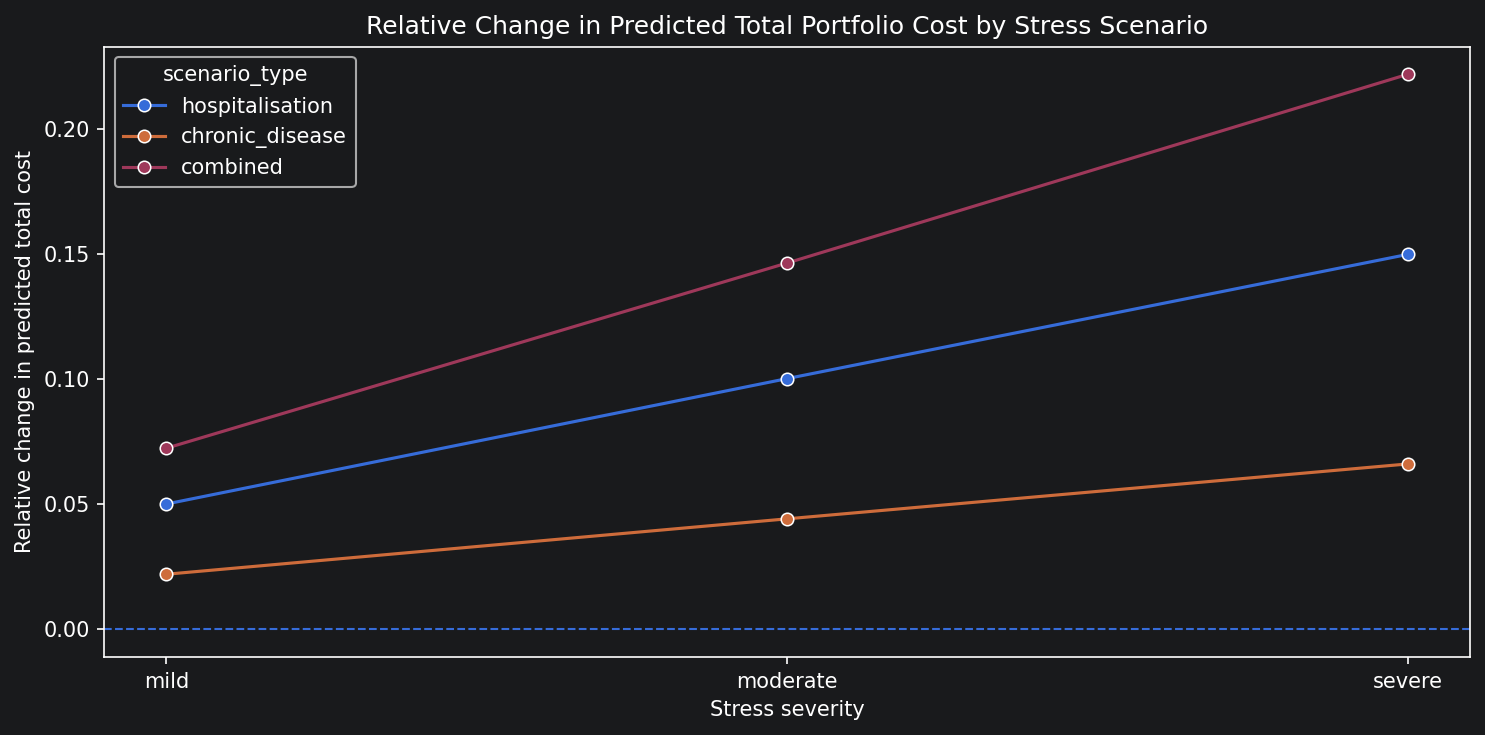

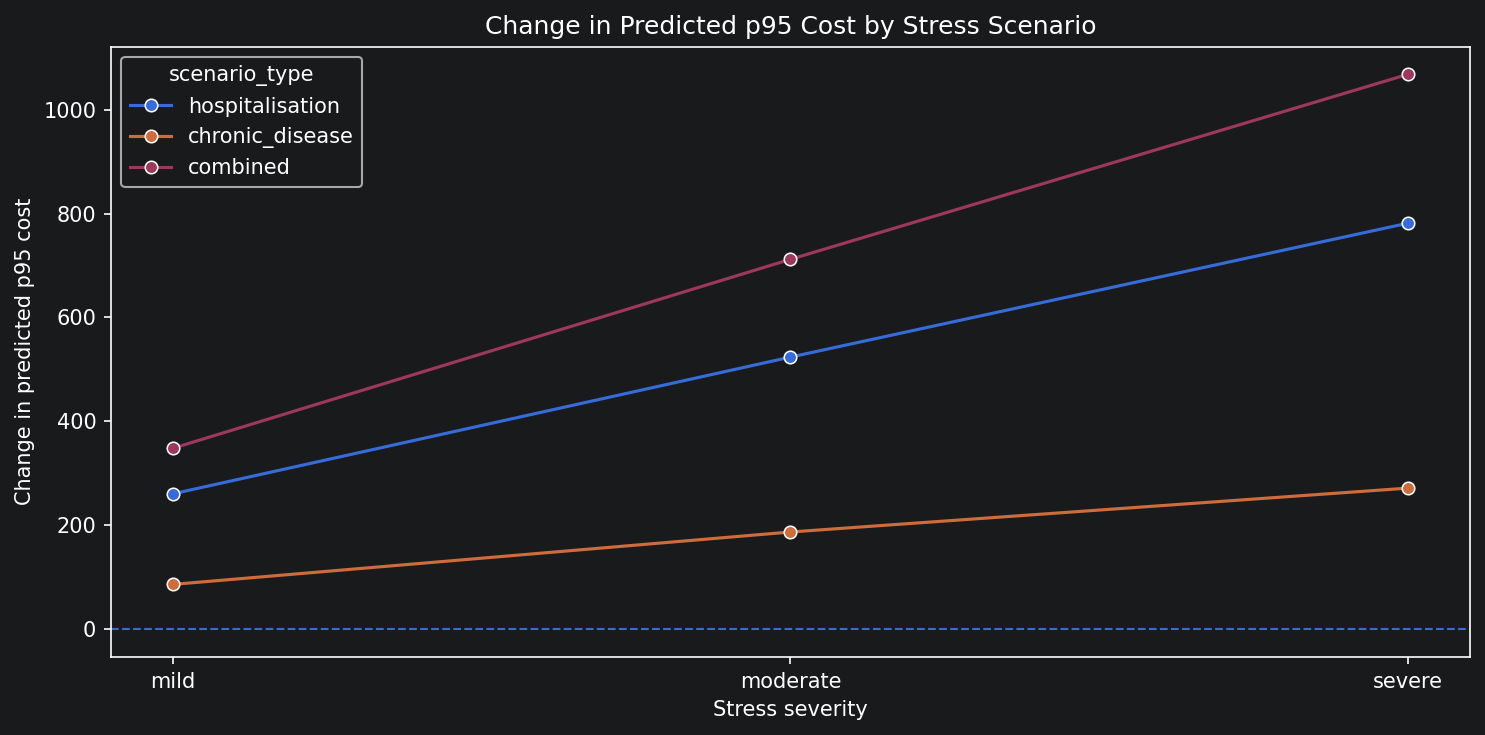

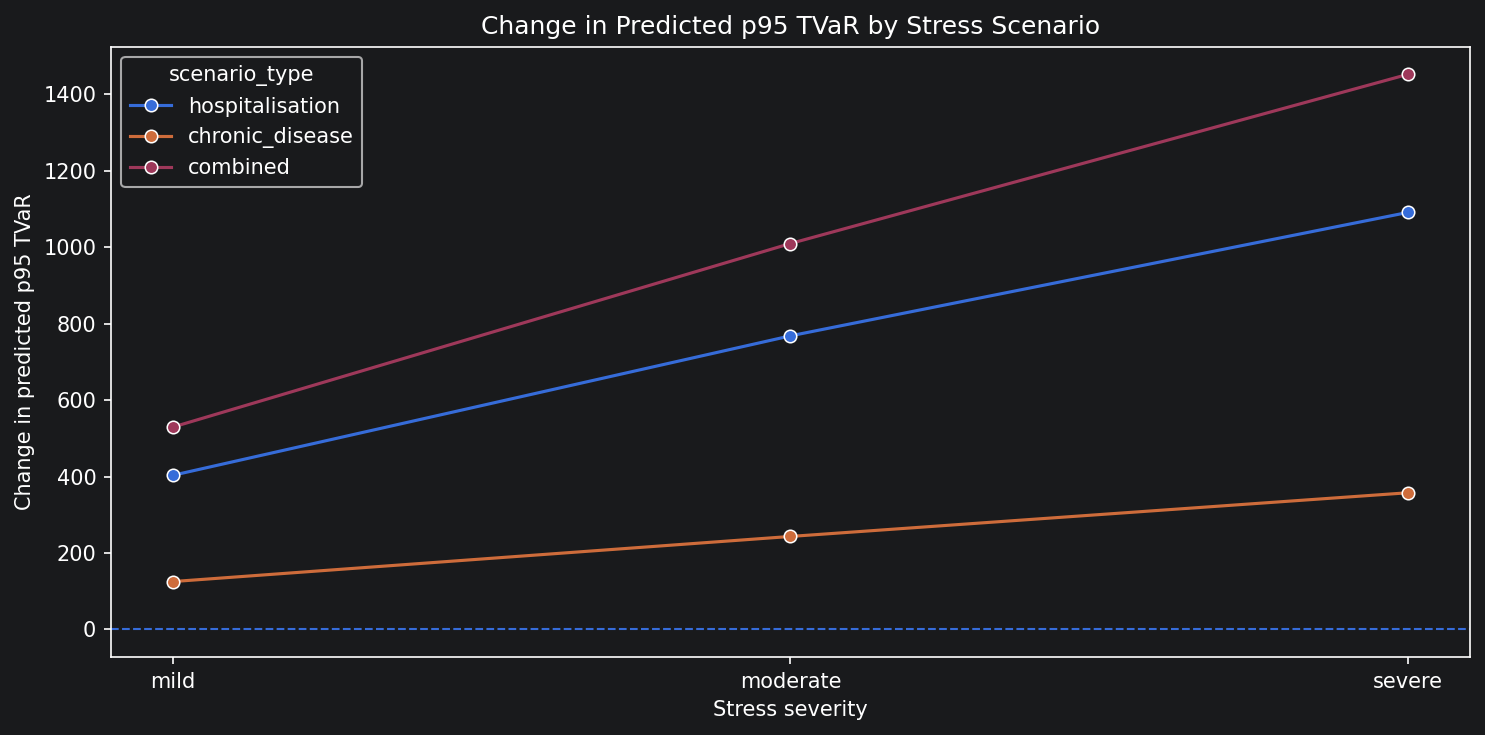

In [10]:
plot_data = scenario_comparison_df[
    scenario_comparison_df["scenario_type"] != "baseline"
    ].copy()

severity_order = ["mild", "moderate", "severe"]
plot_data["severity"] = pd.Categorical(
    plot_data["severity"],
    categories=severity_order,
    ordered=True,
)

plt.figure(figsize=(10, 5), dpi=150)
sns.lineplot(
    data=plot_data,
    x="severity",
    y="total_predicted_cost_pct_change",
    hue="scenario_type",
    marker="o",
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Relative Change in Predicted Total Portfolio Cost by Stress Scenario")
plt.xlabel("Stress severity")
plt.ylabel("Relative change in predicted total cost")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5), dpi=150)
sns.lineplot(
    data=plot_data,
    x="severity",
    y="p95_predicted_cost_change",
    hue="scenario_type",
    marker="o",
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Change in Predicted p95 Cost by Stress Scenario")
plt.xlabel("Stress severity")
plt.ylabel("Change in predicted p95 cost")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5), dpi=150)
sns.lineplot(
    data=plot_data,
    x="severity",
    y="tvar_p95_change",
    hue="scenario_type",
    marker="o",
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Change in Predicted p95 TVaR by Stress Scenario")
plt.xlabel("Stress severity")
plt.ylabel("Change in predicted p95 TVaR")
plt.tight_layout()
plt.show()

In [11]:
def grouped_distribution_table(
        base_df: pd.DataFrame,
        stressed_df: pd.DataFrame,
        column: str,
) -> pd.DataFrame:
    base_counts = (
        base_df[column]
        .astype(str)
        .value_counts(normalize=False)
        .rename("baseline_count")
    )

    stressed_counts = (
        stressed_df[column]
        .astype(str)
        .value_counts(normalize=False)
        .rename("stressed_count")
    )

    base_pct = (
        base_df[column]
        .astype(str)
        .value_counts(normalize=True)
        .rename("baseline_pct")
    )

    stressed_pct = (
        stressed_df[column]
        .astype(str)
        .value_counts(normalize=True)
        .rename("stressed_pct")
    )

    output = pd.DataFrame(index=base_counts.index.union(stressed_counts.index))

    output["baseline_count"] = base_counts.reindex(output.index, fill_value=0).astype(int)
    output["stressed_count"] = stressed_counts.reindex(output.index, fill_value=0).astype(int)
    output["count_change"] = output["stressed_count"] - output["baseline_count"]

    output["baseline_pct"] = base_pct.reindex(output.index, fill_value=0.0)
    output["stressed_pct"] = stressed_pct.reindex(output.index, fill_value=0.0)
    output["pct_point_change"] = output["stressed_pct"] - output["baseline_pct"]

    output = output.reset_index()
    output = output.rename(columns={"index": column})

    return output


combined_severe_df, combined_severe_metadata = apply_combined_stress(
    df,
    stress_fraction=STRESS_LEVELS["severe"],
    random_state=RANDOM_STATE,
)

for column in [
    "hospitalizations_grouped",
    "days_hospitalized_grouped",
    "chronic_count_grouped",
]:
    print(column)
    display(grouped_distribution_table(df, combined_severe_df, column))

hospitalizations_grouped


,hospitalizations_grouped,baseline_count,stressed_count,count_change,baseline_pct,stressed_pct,pct_point_change
0,0,91031,63708,-27323,0.9103,0.6371,-0.2732
1,1,8582,33344,24762,0.0858,0.3334,0.2476
2,2+,387,2948,2561,0.0039,0.0295,0.0256


days_hospitalized_grouped


,days_hospitalized_grouped,baseline_count,stressed_count,count_change,baseline_pct,stressed_pct,pct_point_change
0,0,91031,63708,-27323,0.9103,0.6371,-0.2732
1,1-3,3778,30001,26223,0.0378,0.3000,0.2622
2,4+,5191,6291,1100,0.0519,0.0629,0.0110


chronic_count_grouped


,chronic_count_grouped,baseline_count,stressed_count,count_change,baseline_pct,stressed_pct,pct_point_change
0,0,46532,32469,-14063,0.4653,0.3247,-0.1406
1,1,37579,40381,2802,0.3758,0.4038,0.0280
2,2,13111,20511,7400,0.1311,0.2051,0.0740
3,3,2452,5595,3143,0.0245,0.0559,0.0314
4,4+,326,1044,718,0.0033,0.0104,0.0072


In [12]:
scenario_summary_path = OUTPUT_DIR / "stress_scenario_summaries.csv"
scenario_comparison_path = OUTPUT_DIR / "stress_scenario_comparison.csv"
aggregate_response_path = OUTPUT_DIR / "stress_aggregate_response_table.csv"
tail_response_path = OUTPUT_DIR / "stress_tail_response_table.csv"
baseline_predictions_path = OUTPUT_DIR / "baseline_portfolio_predictions.csv"
scenario_predictions_path = OUTPUT_DIR / "stress_scenario_predictions_wide.csv"
model_path = OUTPUT_DIR / "stress_model_result.joblib"

scenario_summary_df.to_csv(scenario_summary_path, index=False)
scenario_comparison_df.to_csv(scenario_comparison_path, index=False)
aggregate_response_table.to_csv(aggregate_response_path, index=False)
tail_response_table.to_csv(tail_response_path, index=False)

baseline_prediction_frame[
    ["actual_cost", "baseline_predicted_cost"]
].to_csv(baseline_predictions_path, index=False)

scenario_predictions_wide = pd.DataFrame({
    scenario: predictions
    for scenario, predictions in scenario_prediction_store.items()
})

scenario_predictions_wide.to_csv(scenario_predictions_path, index=False)

joblib.dump(stress_model_result, model_path)

print("Saved:")
for path in [
    scenario_summary_path,
    scenario_comparison_path,
    aggregate_response_path,
    tail_response_path,
    baseline_predictions_path,
    scenario_predictions_path,
    model_path,
]:
    print(path)

Saved:
C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\07_stress_scenario_analysis\stress_scenario_summaries.csv
C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\07_stress_scenario_analysis\stress_scenario_comparison.csv
C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\07_stress_scenario_analysis\stress_aggregate_response_table.csv
C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\07_stress_scenario_analysis\stress_tail_response_table.csv
C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\07_stress_scenario_analysis\baseline_portfolio_predictions.csv
C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\07_stress_scenario_analysis\stress_scenario_pred